# Imports and Clean

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
LoanID            0
Age               0
Income            0
LoanAmount        0
CreditScore       0
MonthsEmployed    0
NumCreditLines    0
InterestRate      0
LoanTerm          0
DTIRatio          0
Education         0
EmploymentType    0
MaritalStatus     0
HasMortgage       0
HasDependents     0
LoanPurpose       0
HasCoSigner       0
Default           0
dtype: int64
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 255347 entries, 0 to 255346
Data columns (total 18 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   LoanID          255347 non-null  object 
 1   Age             255347 non-null  int64  
 2   Income          255347 non-null  int64  
 3   LoanAmount      255347 non-null  int64  
 4   CreditScore     255347 non-null  int64  
 5   MonthsEmployed  255347 non-null  int64  
 6   NumCreditLines

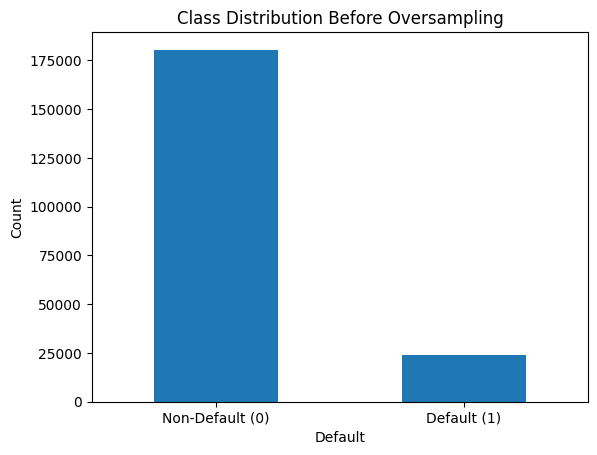

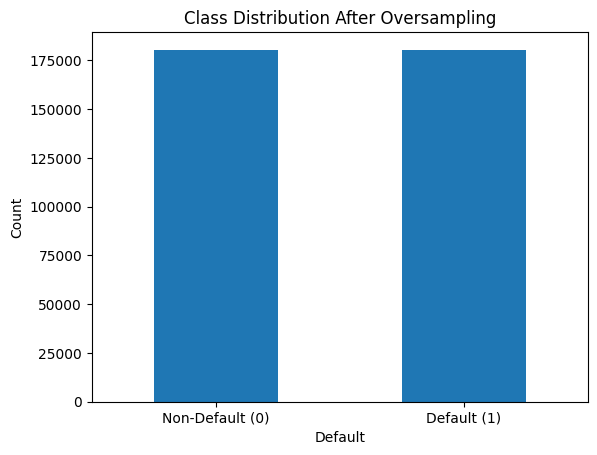

In [5]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from google.colab import drive

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_curve,
    roc_auc_score
)

from imblearn.over_sampling import RandomOverSampler


drive.mount('/content/drive')



df = pd.read_csv("/content/drive/MyDrive/data/Loan_default.csv")
#df = df.sample(random_state=42).copy()


# remove duplicates
df = df.drop_duplicates()

# check nulls
print(df.isnull().sum())

# preview
df.info(verbose=True)

# define features and target
y = df["Default"]
X = df.drop("Default", axis=1)
X = X.drop("LoanID", axis=1)

# encode categorical variables
X = pd.get_dummies(X, drop_first=True)

print("Shape after encoding:", X.shape)

# test / train split of data
# 80/20 split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

y_train.value_counts().plot(kind="bar")
plt.title("Class Distribution Before Oversampling")
plt.xlabel("Default")
plt.ylabel("Count")
plt.xticks([0,1], ["Non-Default (0)", "Default (1)"], rotation=0)
plt.show()

# CLASS BALANCING
ros = RandomOverSampler(random_state=42)
X_train_resampled, y_train_resampled = ros.fit_resample(X_train, y_train)

y_train_resampled.value_counts().plot(kind="bar")
plt.title("Class Distribution After Oversampling")
plt.xlabel("Default")
plt.ylabel("Count")
plt.xticks([0,1], ["Non-Default (0)", "Default (1)"], rotation=0)
plt.show()

# scale features for logistic regression
scaler = StandardScaler()
X_train_scaled_resampled = scaler.fit_transform(X_train_resampled)
X_test_scaled = scaler.transform(X_test)


#Logistic Regression

In [35]:
# ---------------------------
# LOGISTIC REGRESSION
# -------------------------

# Creation of actual model
# max_iter=500 - max 500 times to find optimal
log_model = LogisticRegression(max_iter=500, random_state=42, class_weight="balanced")

# Training of model
log_model.fit(X_train_scaled_resampled, y_train_resampled)

# Predictions and Plots
y_pred_log = log_model.predict(X_test_scaled)
y_prob_log = log_model.predict_proba(X_test_scaled)[:, 1]
print("Logistic Accuracy:", accuracy_score(y_test, y_pred_log))
print(confusion_matrix(y_test, y_pred_log))

Logistic Accuracy: 0.6783434501664383
[[30535 14635]
 [ 1792  4108]]


#DECISION TREE

In [36]:
# ---------------------------
# Decision Tree
# -------------------------


# Creation of model
# criterion='entropy' - attempt to reduce entropy and MAXIMISE information gain
tree_model = DecisionTreeClassifier(
    criterion="entropy",
    max_depth=5,
    random_state=42,
    class_weight="balanced"
)

# Training of model
tree_model.fit(X_train_resampled, y_train_resampled)


# Predictions and Plots
y_pred_tree = tree_model.predict(X_test)
y_prob_tree = tree_model.predict_proba(X_test)[:, 1]

#
print("\n=========================")
print("DECISION TREE RESULTS")
print("=============================")
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_tree))
print("Accuracy :", accuracy_score(y_test, y_pred_tree))
print("Precision:", precision_score(y_test, y_pred_tree))
print("Recall   :", recall_score(y_test, y_pred_tree))
print("F1 Score :", f1_score(y_test, y_pred_tree))
print("ROC AUC  :", roc_auc_score(y_test, y_prob_tree))


DECISION TREE RESULTS
Confusion Matrix:
[[31389 13781]
 [ 2210  3690]]
Accuracy : 0.6868807519091443
Precision: 0.21120714326598364
Recall   : 0.6254237288135593
F1 Score : 0.31577596166188865
ROC AUC  : 0.7122229412051646


#GRADIENT BOOSTING

In [37]:
# ---------------------------
# Gradient Boosting
# -------------------------

# Creating the model
# n_estimators=100 - 100 sequential DT's
# learning_rate=0.1 -
gbm_model = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.1,
    random_state=42
)

# Train the model
gbm_model.fit(X_train_resampled, y_train_resampled)

# Predictions and Plots
y_pred_gbm = gbm_model.predict(X_test)
y_prob_gbm = gbm_model.predict_proba(X_test)[:, 1]
print("\n=============================")
print("GRADIENT BOOSTING RESULTS")
print("============================")
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_gbm))
print("Accuracy :", accuracy_score(y_test, y_pred_gbm))
print("Precision:", precision_score(y_test, y_pred_gbm))
print("Recall   :", recall_score(y_test, y_pred_gbm))
print("F1 Score :", f1_score(y_test, y_pred_gbm))
print("ROC AUC  :", roc_auc_score(y_test, y_prob_gbm))


GRADIENT BOOSTING RESULTS
Confusion Matrix:
[[31170 14000]
 [ 1855  4045]]
Accuracy : 0.689543763461915
Precision: 0.22416181767802715
Recall   : 0.6855932203389831
F1 Score : 0.33785759031112966
ROC AUC  : 0.7566885851191169


#ROC CHart

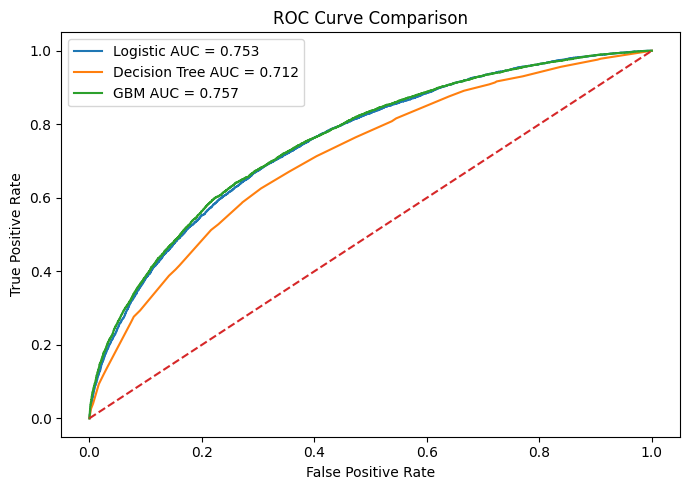

In [38]:
# Define false and true postitive
fpr_log, tpr_log, _ = roc_curve(y_test, y_prob_log)
fpr_tree, tpr_tree, _ = roc_curve(y_test, y_prob_tree)
fpr_gbm, tpr_gbm, _ = roc_curve(y_test, y_prob_gbm)

# Plot and Vsiausl
plt.figure(figsize=(7, 5))
plt.plot(fpr_log, tpr_log, label=f"Logistic AUC= {roc_auc_score(y_test, y_prob_log):.3f}")
plt.plot(fpr_tree, tpr_tree, label=f"Decision Tree AUC = {roc_auc_score(y_test, y_prob_tree):.3f}")
plt.plot(fpr_gbm, tpr_gbm, label=f"GBM AUC= {roc_auc_score(y_test, y_prob_gbm):.3f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.tight_layout()
plt.show()

# Table of Comparison

In [39]:
# Table of Comparison
summary = pd.DataFrame([
    {
        "Model": "Logistic Regression",
        "Accuracy": accuracy_score(y_test, y_pred_log),
        "Precision": precision_score(y_test, y_pred_log),
        "Recall": recall_score(y_test, y_pred_log),
        "F1 Score": f1_score(y_test, y_pred_log),
        "ROC AUC": roc_auc_score(y_test, y_prob_log)
    },
    {
        "Model": "Decision Tree",
        "Accuracy": accuracy_score(y_test, y_pred_tree),
        "Precision": precision_score(y_test, y_pred_tree),
        "Recall": recall_score(y_test, y_pred_tree),
        "F1 Score": f1_score(y_test, y_pred_tree),
        "ROC AUC": roc_auc_score(y_test, y_prob_tree)
    },
    {
        "Model": "Gradient Boosting",
        "Accuracy": accuracy_score(y_test, y_pred_gbm),
        "Precision": precision_score(y_test, y_pred_gbm),
        "Recall": recall_score(y_test, y_pred_gbm),
        "F1 Score": f1_score(y_test, y_pred_gbm),
        "ROC AUC": roc_auc_score(y_test, y_prob_gbm)
    }
])

print(summary.sort_values(by="F1 Score", ascending=False))

                 Model  Accuracy  Precision    Recall  F1 Score   ROC AUC
2    Gradient Boosting  0.689544   0.224162  0.685593  0.337858  0.756689
0  Logistic Regression  0.678343   0.219175  0.696271  0.333401  0.752761
1        Decision Tree  0.686881   0.211207  0.625424  0.315776  0.712223


# GBM Feature Importance Table

                         Feature  Importance
0                            Age    0.335609
6                   InterestRate    0.199922
1                         Income    0.169699
4                 MonthsEmployed    0.105606
2                     LoanAmount    0.091609
23               HasCoSigner_Yes    0.016847
3                    CreditScore    0.014776
18             HasDependents_Yes    0.012557
14     EmploymentType_Unemployed    0.011646
5                 NumCreditLines    0.008331
15         MaritalStatus_Married    0.006089
17               HasMortgage_Yes    0.005028
8                       DTIRatio    0.004535
13  EmploymentType_Self-employed    0.004242
21              LoanPurpose_Home    0.004189


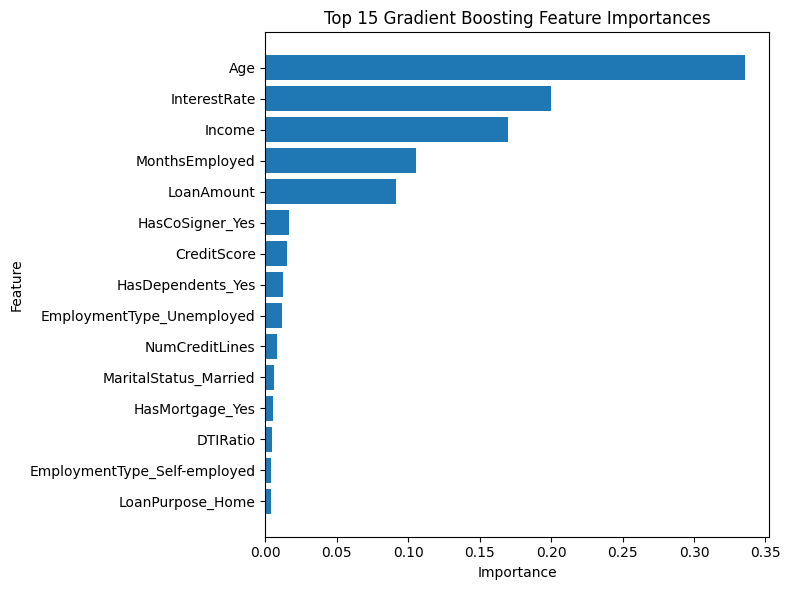

In [40]:

# dataFrame
gbm_feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": gbm_model.feature_importances_
}).sort_values(by="Importance", ascending=False)

# Plot and Visuals
print(gbm_feature_importance.head(15))
plt.figure(figsize=(8, 6))
top15_gbm = gbm_feature_importance.head(15)
plt.barh(top15_gbm["Feature"], top15_gbm["Importance"])
plt.title("Top 15 Gradient Boosting Feature Importances ")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()